In [1]:
# setting root at top

import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

# EnhancedNormModel 64x64 Image and 4 Conv Blocks
# Using OverSampled high-alert and 0.002 Learning Rate

### Import libraries
* `torch`
* `datasets` and `transforms` from `torchvision` for data Loading.
* `DataLoader` and `WeightedRandomSampler` from `torch.utils.data` for Batching and using data in model.
* `NormModel` from `architectures.NormModel.py`
* `pandas` as `pd`
* `matplotlib.pyplot` as `plt`
* `seaborn` as sns
* `trainer` from `modules.TrainTest`
* `oversampler` from `modules.OverSampler`

In [2]:
# training and architecture
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from architectures.EnhancedNormModel import EnhancedNormModel

# visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#trainer and tester modules
from modules.TrainTest import trainer
from modules.OverSampler import oversampler

### Load datasets for training
* load 64x64 images
* load from `../dataset/final-dataset/train`
* convert to tensor
* make batch_size = 32

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2)
])

train_dataset = datasets.ImageFolder(
    root="../dataset/final-dataset/train",
    transform=train_transform
)

sampler = oversampler(
    dataset=train_dataset,
    oversample_rate= 2
)


In [4]:

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    sampler = sampler
)

### Load datasets for training
* load 64x64 images
* load from `../dataset/final-dataset/train`
* convert to tensor
* make batch_size = 32

In [5]:
valid_transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor()
    ]
)

valid_dataset = datasets.ImageFolder(
    root="../dataset/final-dataset/valid",
    transform=valid_transform
)

valid_dataloader = DataLoader(
    dataset=valid_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

### Use Model for training
Initialize model using 
* `conv_layers = 4`, 
* `initial_output_channel = 16` 
* `initial_image_size = 64`
* `poolings = [1,1,1,1]`
* `normalizations = [1, 1, 1, 1]`,
* `dropouts = [0, 1, 0, 1]`

In [6]:
model = EnhancedNormModel(
    conv_layers=4, 
    normalizations = [1, 1, 1, 1],
    poolings = [1,1,1,1],
    dropouts = [0, 1, 0, 1],
    initial_output_channel=16, 
    initial_image_size=64,
    dropout_p = 0.2
    ).to("cuda")

In [ ]:
metrics = trainer(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=valid_dataloader,
    epoch=30,
    lr=0.002,
    print_on=1,
    save_dir="../models/en_norm_img64_c4_lr_0.002_os/",
    save_checkpoints=1,
    checkpoint_name="en_norm_64x64_train_0_",
    early_stop_patience = 20,
    min_delta = 0.01
)

Epoch 1/30 | Train Loss: 0.9583 | Valid Loss: 1.0205
Epoch 2/30 | Train Loss: 0.8248 | Valid Loss: 0.8171
Epoch 3/30 | Train Loss: 0.7587 | Valid Loss: 0.8071
Epoch 4/30 | Train Loss: 0.7071 | Valid Loss: 0.8598
Epoch 5/30 | Train Loss: 0.6599 | Valid Loss: 0.7336
Epoch 6/30 | Train Loss: 0.6230 | Valid Loss: 0.7388
Epoch 7/30 | Train Loss: 0.5939 | Valid Loss: 0.7118
Epoch 8/30 | Train Loss: 0.5603 | Valid Loss: 0.8070
Epoch 9/30 | Train Loss: 0.5297 | Valid Loss: 0.7711
Epoch 10/30 | Train Loss: 0.5200 | Valid Loss: 0.6217
Epoch 11/30 | Train Loss: 0.4985 | Valid Loss: 0.7059
Epoch 12/30 | Train Loss: 0.4701 | Valid Loss: 0.6273
Epoch 13/30 | Train Loss: 0.4618 | Valid Loss: 0.6332
Epoch 14/30 | Train Loss: 0.4389 | Valid Loss: 0.6110
Epoch 15/30 | Train Loss: 0.4218 | Valid Loss: 0.6188
Epoch 16/30 | Train Loss: 0.4108 | Valid Loss: 0.6124
Epoch 17/30 | Train Loss: 0.4062 | Valid Loss: 0.7670
Epoch 18/30 | Train Loss: 0.3936 | Valid Loss: 0.7366
Epoch 19/30 | Train Loss: 0.3834 | Va

## Visualize

Convert metrics to a pd.DataFrame and add epoch column for visualization.

In [8]:
metrics = pd.DataFrame(metrics)
epochs = [i+1 for i  in range(len(metrics))]
metrics["epoch"] = epochs

In [9]:
metrics

,epoch,training_loss,training_accuracy,training_precision,training_recall,training_f1,valid_loss,valid_accuracy,valid_precision,valid_recall,valid_f1
0,1,0.958279,0.528370,0.526472,0.528437,0.527100,1.020479,0.503177,0.557222,0.468540,0.396950
1,2,0.824774,0.621858,0.619842,0.621903,0.620387,0.817059,0.648878,0.573767,0.637379,0.567790
2,3,0.758688,0.662022,0.660526,0.662375,0.661033,0.807082,0.598052,0.587616,0.547009,0.487546
3,4,0.707138,0.693944,0.692586,0.694606,0.693059,0.859848,0.627700,0.582990,0.613475,0.545281
4,5,0.659935,0.717942,0.716006,0.718419,0.716567,0.733555,0.647183,0.588484,0.565692,0.542268
5,6,0.622980,0.734107,0.732056,0.734117,0.732442,0.738796,0.684879,0.590835,0.663634,0.604191
6,7,0.593916,0.747177,0.745054,0.747058,0.745523,0.711821,0.669208,0.580539,0.536063,0.550614
7,8,0.560286,0.769581,0.767390,0.769024,0.767637,0.806980,0.655654,0.635670,0.617484,0.589329
8,9,0.529723,0.783424,0.780683,0.782443,0.781066,0.771140,0.669208,0.615020,0.631676,0.588408
9,10,0.519966,0.785337,0.783129,0.784925,0.783461,0.621653,0.743753,0.663923,0.613488,0.629903


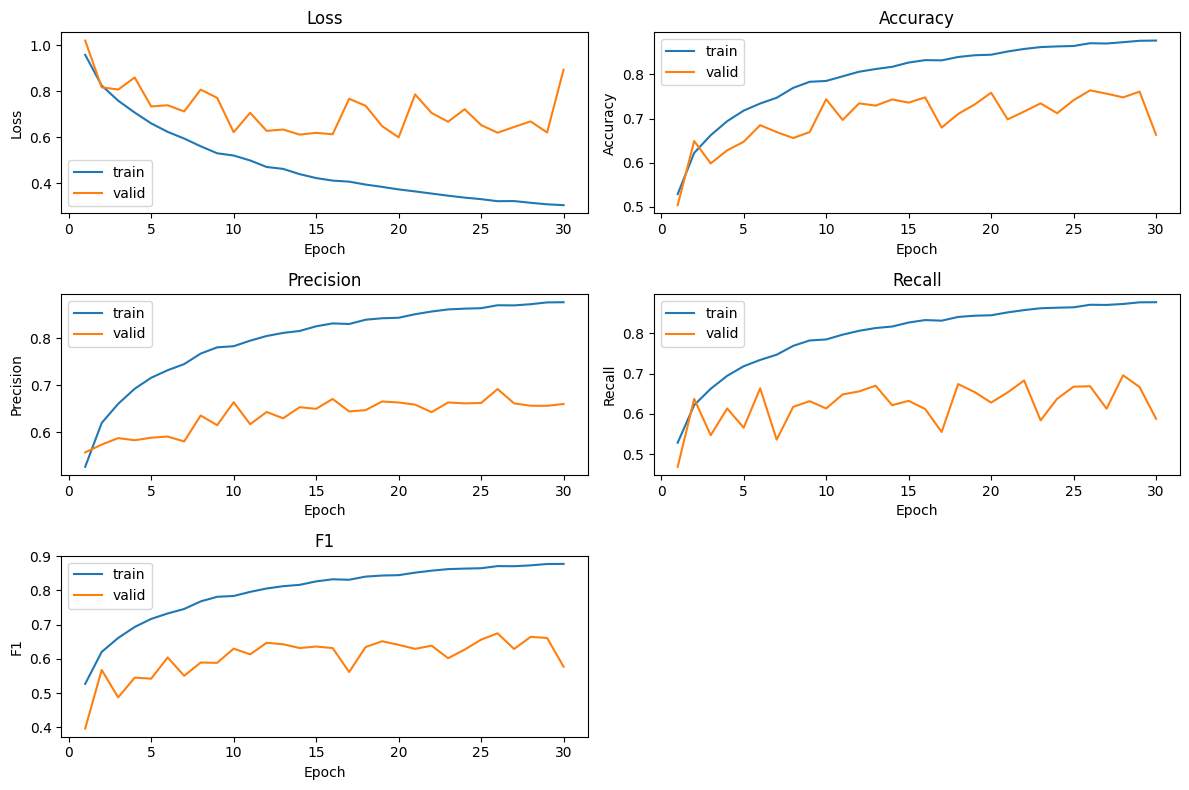

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

to_viz = [
    "loss",
    "accuracy",
    "precision",
    "recall",
    "f1"
]

for i, metric in enumerate(to_viz):

    ax = axes[i]

    sns.lineplot(
        data=metrics,
        x="epoch",
        y=f"training_{metric}",
        ax=ax,
        label="train"
    )

    sns.lineplot(
        data=metrics,
        x="epoch",
        y=f"valid_{metric}",
        ax=ax,
        label="valid"
    )

    ax.set_title(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric.capitalize())

# Hide unused subplot (6th slot)
axes[-1].axis("off")

plt.tight_layout()
plt.show()